# 서울시 상권 폐업위험 예측 모델

> **핵심 질문** — 다음 분기에 점포 순감소(폐업 > 개업)로 전환될 상권 × 업종은 어디이며, 무엇이 위험을 만드는가

요식업 10종 · 서울시 전체 상권 4유형 · 2023Q1~2025Q4 · 67,475칸 · 순감소 25.5%

본 문서는 분석 코드를 제외하고 출력물과 판단만 담음.


## 한 장 요약

| 절 | 제목 | 핵심 한 줄 |
|---|---|---|
| 01 | 분석 개요 | 다음 분기에 폐업 수가 개업 수보다 많아질 ‘상권×업종’을 한 분기 먼저 찾고, 그 위험이 어디에서 오는지 설명하는 것이 목표다. |
| 02 | 데이터와 전처리 판단 | 결측을 무조건 지우지 않고, 왜 비어 있는지부터 판단했다. 특히 매출 결측은 영세 상권의 특성을 담을 수 있어 그대로 정보로 남겼다. |
| 03 | 라벨의 구조 — y=0에 섞여 있는 두 상태 | 순감소가 아닌 y=0에는 “성장·유지”뿐 아니라 “아무 변화가 없었던 곳”도 많이 섞여 있다. 이 때문에 단순 모델은 위험보다 상권 규모를 먼저 배울 수 있다. |
| 04 | 기초 탐색과 상권유형별 차이 | 상권유형별 순감소율 차이는 통계적으로는 분명했지만, 실제 차이의 크기는 작았다. “유형 자체가 위험을 만든다”고 바로 결론낼 정도는 아니었다. |
| 05 | 비교 기준 — 모델이 넘어야 하는 선 | 예측모델은 무작위보다만 좋아서는 부족하다. 점포 수 하나만으로도 상당히 맞힐 수 있기 때문에, 실제 기준선은 “점포 수 규칙”이다. |
| 06 | 점포 수를 고정하면 무엇이 남는가 | 점포 수가 비슷한 상권끼리 비교하자 “골목상권은 안전하다”는 단순 결론이 뒤집혔다. 규모가 상권유형과 위험 사이를 강하게 교란하고 있었다. |
| 07 | 검정 방법의 선택 — 정규성과 등분산성 | 데이터 분포가 정규분포와 거리가 있고 일부 집단은 분산도 달랐기 때문에, 평균 비교보다 순위 기반의 Kruskal-Wallis 검정을 주 검정으로 사용했다. |
| 08 | 가설 직접 검증 — 업종 × 상권유형 · 업종 × 자치구 | 같은 업종이라도 상권유형에 따라 위험이 달라지는 경우가 많았지만, 그 영향의 크기는 업종마다 크게 달랐다. 자치구 효과는 상대적으로 약했다. |
| 09 | 성향점수매칭 — 조건을 맞추고 다시 비교 | 한식음식점은 단순 비교에서는 더 위험해 보였지만, 규모와 입지가 비슷한 곳끼리 짝지으니 오히려 순감소 위험이 낮았다. |
| 10 | 사후검정 — 어느 상권유형이 실제로 다른가 | 전체적으로 차이가 있다는 것만으로는 부족해, Dunn 사후검정으로 상권유형을 두 개씩 비교했다. 전통시장과 골목상권만 뚜렷하게 구분되지 않았다. |
| 11 | 모델 선정 | 다섯 모델의 AP가 0.398~0.408에 몰려 있어 “어떤 알고리즘을 쓰느냐”보다 해석과 운영 설계가 더 중요했다. |
| 12 | 선정 규모 — 몇 곳을 위험 대상으로 볼 것인가 | 모델은 많은 곳을 넓게 잡을 때보다, 실제 담당자가 볼 수 있는 상위 수십~수백 곳을 우선 선별할 때 가장 유용했다. |
| 13 | 테스트 최종 평가 — 2026년 1분기 결과 | 학습과 모델 선택에 쓰지 않은 홀드아웃 분기에서 AP 0.399, Lift 1.522를 기록했다. 전체 순위 성능은 점포 수 기준과 비슷했지만, 상위 소수 구간에서는 모델이 더 강했다. |
| 14 | 두 단계로 나눈 모형 | 순감소를 “① 다음 분기에 개·폐업이 일어나는가”와 “② 일어났다면 감소 방향인가”로 나누자, 상권 규모 효과가 대부분 1단계에 모여 있음을 확인했다. |
| 15 | 두 확률로 나눈 상권 유형 | 최종 위험점수 하나로만 줄 세우지 않고 “변화가 자주 생기는가”와 “변하면 감소하는가”를 두 축으로 남기면 성격이 다른 네 유형을 구분할 수 있다. |
| 16 | 무엇이 위험과 관련되어 있는가 | 단일 모델에서는 규모·밀도 변수가 기여도의 절반 이상을 차지했지만, 사건과 방향을 분리하자 규모 영향은 주로 1단계에 남고 2단계에서는 크게 줄었다. |
| 17 | 위험도 공간 분석 | 지도에서는 위험등급이 높아질수록 실제 순감소율도 15.3% → 39.3%로 증가했다. 다만 자치구 경계나 역과의 거리 자체는 위험을 잘 설명하지 못했다. |
| 18 | 종합 결론 | 다음 분기 순감소를 완벽하게 예측한 것은 아니지만, 상위 소수 고위험 상권을 한 분기 먼저 선별하고 규모에 가려진 위험 구조를 분리해 설명할 수 있었다. |


## 01  분석 개요

**핵심 한 줄 — 다음 분기에 폐업 수가 개업 수보다 많아질 ‘상권×업종’을 한 분기 먼저 찾고, 그 위험이 어디에서 오는지 설명하는 것이 목표다.**

### 왜 이 분석을 했나

연구 질문과 분석 단위를 먼저 고정해, 뒤의 통계검정과 예측모델이 같은 대상을 보고 있는지 명확히 했다.

### 핵심 결과

- 분석 단위는 상권 × 요식업 업종 × 분기이다. 업종은 한식·중식·일식·양식·제과·패스트푸드·치킨·분식·호프·커피 등 10종이다.
- 기간은 2023년 1분기~2025년 4분기이며, 2026년 1분기는 2025년 4분기의 “다음 분기 결과”를 만들기 위해서만 사용했다.
- 라벨은 “다음 분기에 폐업 수 > 개업 수인가”이다. 매출 감소가 아니라 실제 점포 수의 순감소를 직접 잡기 위한 선택이다.

| 항목 | 핵심 수치 / 의미 |
|---|---|
| 최종 표본 | 점포 5개 이상인 상권×업종×분기 67,475건 |
| 순감소 비율 | 25.5% |
| 예측 목표 | 다음 분기의 순감소 여부 |
| 핵심 산출물 | 위험순위 + 위험요인 + 상권 유형화 |

*표 1*



### 해석

따라서 이 보고서의 “폐업위험”은 개별 가게의 폐업확률이 아니라, 특정 상권의 특정 업종에서 다음 분기에 점포 수가 순감소할 가능성을 뜻한다.



## 02  데이터와 전처리 판단

**핵심 한 줄 — 결측을 무조건 지우지 않고, 왜 비어 있는지부터 판단했다. 특히 매출 결측은 영세 상권의 특성을 담을 수 있어 그대로 정보로 남겼다.**

### 왜 이 분석을 했나

잘못된 결측 처리나 중복 변수를 넣으면 표본이 줄거나 같은 정보를 여러 번 세어 모델 해석이 왜곡될 수 있다.

### 핵심 결과

- 원천은 서울시 우리마을가게 상권분석서비스이다. 매출은 카드 결제 기반 추정치, 유동인구는 생활인구, 점포는 사업자등록 자료를 사용한다.
- “폐업”은 실제 문을 닫은 날짜가 아니라 사업자등록 말소 시점이다. 따라서 실제 폐점 시점과 시차가 있을 수 있다.
- 집객시설의 빈칸은 시설이 없음을 뜻하는 자료 구조로 판단해 0으로 처리했다.
- 유동인구가 상주·직장 인구 정보를 이미 포함하므로 인구 변수를 중복해서 넣지 않았다. 직장인구 비중은 단독 판별력이 낮아(AUC 0.520) 제외했다.

| 항목 | 핵심 수치 / 의미 |
|---|---|
| 매출 결측률 | 45.4% |
| 매출 결측 처리 | 행 삭제 대신 “매출이 관측되지 않음” 자체를 정보로 유지 |
| 기타 핵심 변수 | 면적·유동인구·점포 수·상권변화지표·운영개월 등은 결측이 거의 없음 |

*표 2*



,컬럼,결측률,판정
0,엑스좌표_값,0.0%,OK
1,영역_면적,0.0%,OK
2,총_유동인구_수,0.0%,OK
3,역세권,2.3%,OK
4,상권_변화_지표,0.0%,OK
5,당월_매출_금액,45.4%,공변량 제외 권장
6,상권_전체점포,0.0%,OK
7,운영_영업_개월_평균,0.0%,OK
8,운영개월_서울대비,0.0%,OK
9,외식물가지수,0.0%,OK


*표 3*

읽는 법 — 결측률 5% 이하는 그대로 쓰고 30%를 넘으면 공변량에서 빼는 기준으로 «판정» 열을 붙였음. 매출 계열만 주의 구간에 들어감.


### 해석

핵심은 “결측=오류”로 단정하지 않은 것이다. 카드 결제가 충분히 잡히지 않는 소규모 상권이라는 특성이 결측에 들어 있을 수 있으므로, 결측 행을 통째로 버리면 오히려 작은 상권을 체계적으로 잃게 된다.



## 03  라벨의 구조 — y=0에 섞여 있는 두 상태

**핵심 한 줄 — 순감소가 아닌 y=0에는 “성장·유지”뿐 아니라 “아무 변화가 없었던 곳”도 많이 섞여 있다. 이 때문에 단순 모델은 위험보다 상권 규모를 먼저 배울 수 있다.**

### 왜 이 분석을 했나

작은 상권은 안전해서가 아니라 점포 수가 적어서 한 분기 동안 개업·폐업이 아예 관측되지 않을 가능성이 높다.

### 핵심 결과

- 전체의 43.9%는 다음 분기에 개업도 폐업도 없는 “변화 없음”이었다.
- y=0인 50,285건 중 58.9%가 “변화 없음”이었다. 즉 y=0을 곧바로 “안전”이라고 해석하면 안 된다.
- 점포 수가 가장 적은 구간에서는 변화 없음이 69.3%였지만, 가장 큰 구간에서는 7.9%까지 떨어졌다. 같은 방향으로 순감소율은 15.1%에서 40.3%로 올라갔다.

| 항목 | 핵심 수치 / 의미 |
|---|---|
| 변화 없음 | 29,633건 · 43.9% |
| 변화는 있었지만 순감소 아님 | 20,652건 · 30.6% |
| 순감소 | 17,190건 · 25.5% |
| 점포 규모 효과 | 평균 5.4개 구간: 변화 없음 69.3% → 평균 65.5개 구간: 7.9% |

*표 4*



,건수,비율
다음 분기 상태,,
변화 없음,29633,0.439
변화 있었으나 줄지 않음,20652,0.306
순감소,17190,0.255


*표 5*

읽는 법 — 다음 분기 상태를 셋으로 나눈 비율임. y=0 은 위 두 줄(변화 없음 + 줄지 않음)의 합임.


,칸수,평균점포,변화없음비율,순감소율
1분위,15520,5.44,0.693,0.151
2분위,14018,7.86,0.599,0.193
3분위,12139,11.73,0.465,0.243
4분위,12718,19.56,0.298,0.308
5분위,13080,65.47,0.079,0.403


*표 6*

읽는 법 — 1분위가 점포가 가장 적은 구간임. «변화없음비율» 열을 위에서 아래로 읽으면 규모가 커질 때 «아무 일도 없음»이 어떻게 줄어드는지 보임.


### 해석

따라서 아무 조정 없이 학습하면 모델은 “어떤 조건에서 쇠퇴하는가”보다 “어디에서 사건이 일어날 만큼 점포가 많은가”를 학습할 수 있다. 이후의 규모 통제와 2단계 모형은 이 문제를 해결하기 위한 장치다.



## 04  기초 탐색과 상권유형별 차이

**핵심 한 줄 — 상권유형별 순감소율 차이는 통계적으로는 분명했지만, 실제 차이의 크기는 작았다. “유형 자체가 위험을 만든다”고 바로 결론낼 정도는 아니었다.**

### 왜 이 분석을 했나

표본이 수만 건이면 아주 작은 차이도 p-value가 매우 작게 나온다. 그래서 “차이가 존재하는가”와 “차이가 큰가”를 함께 봐야 한다.

### 핵심 결과

- 상권유형 × 순감소 카이제곱 검정은 유의했지만 Cramér’s V=0.071로 효과크기는 작았다.
- Kruskal-Wallis도 유의했지만 ε²=0.0050으로 실제 차이는 크지 않았다.
- 변수 간 상관은 일부 높았지만 |r|>0.8인 쌍은 없었다. 가장 큰 상관은 업종밀도와 업종점포비중(r=0.753)이었다.

| 항목 | 핵심 수치 / 의미 |
|---|---|
| 통계적 차이 | χ²(3)=337.9, p<0.001 |
| 효과크기 | Cramér’s V=0.071 · ε²=0.0050 → 작음 |
| 해석 주의 | 상권유형 안에 규모와 업종 구성이 섞여 있으므로 추가 통제가 필요 |

*표 7*



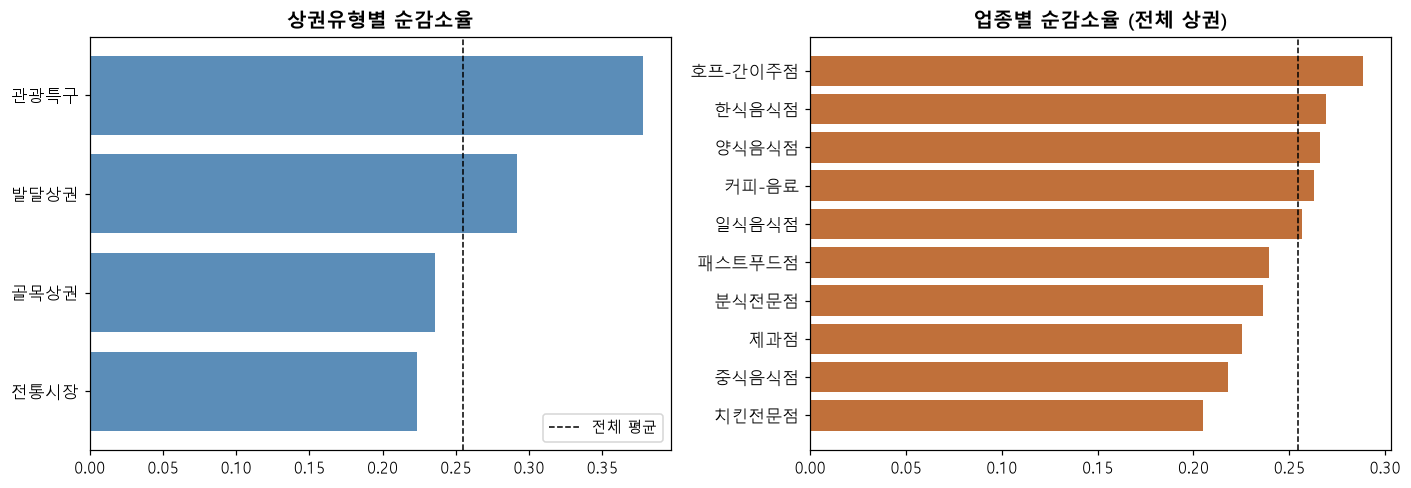

*그림 1*

읽는 법 — 왼쪽이 유형별, 오른쪽이 업종별 순감소율이고 점선이 전체 평균임.


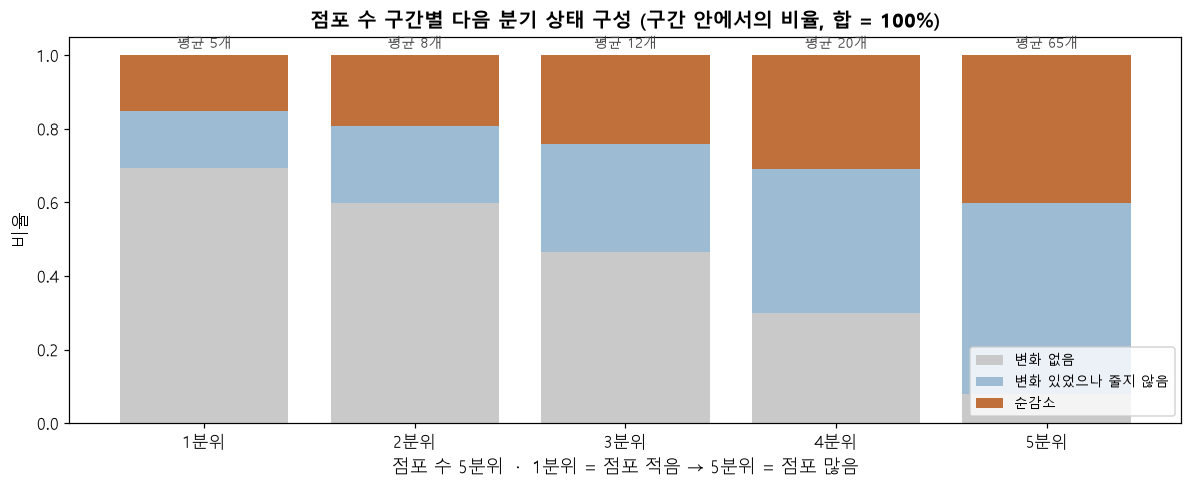

*그림 2*

읽는 법 — 구간 안에서의 비율이라 막대 하나의 합이 100%임. 회색이 «변화 없음»이고, 왼쪽으로 갈수록 회색이 커지는 것이 규모 편향의 통로임.


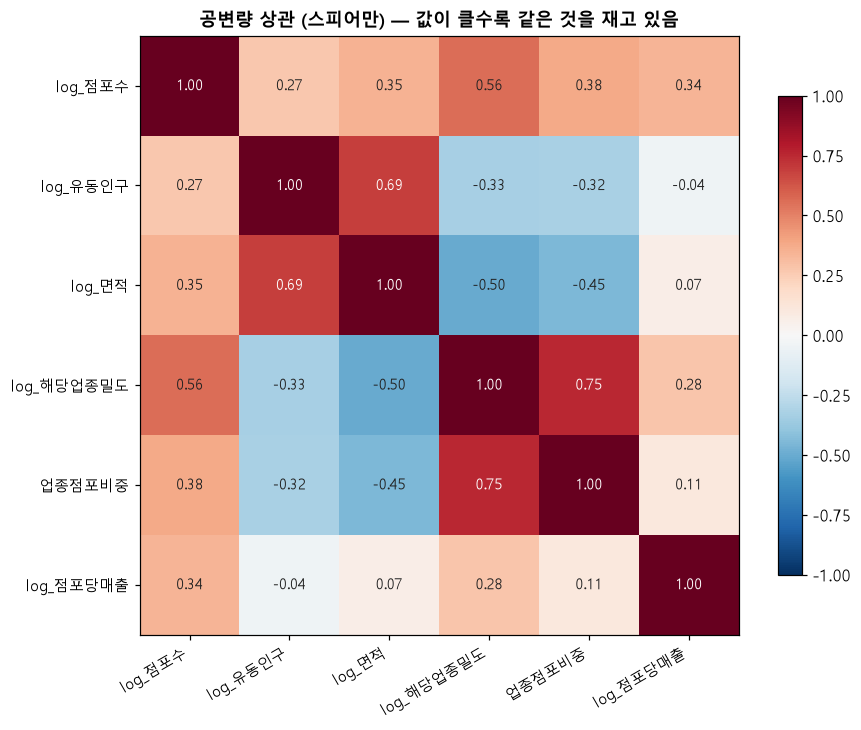

*그림 3*

읽는 법 — 공변량끼리 얼마나 «같은 것을 재고 있는가»임. 붉을수록 강한 양의 상관이고, 0.7 안팎으로 붙어 있는 «업종 밀도 ↔ 업종 점포 비중»과 «유동인구 ↔ 면적»은 각각 한 덩어리로 읽어야 함.


### 해석

이 단계의 결론은 “상권유형별 차이가 아예 없다”도, “상권유형이 원인이다”도 아니다. 차이는 보이지만 그 크기가 작으므로, 점포 수와 업종 구성을 분리한 뒤 다시 확인해야 한다.



## 05  비교 기준 — 모델이 넘어야 하는 선

**핵심 한 줄 — 예측모델은 무작위보다만 좋아서는 부족하다. 점포 수 하나만으로도 상당히 맞힐 수 있기 때문에, 실제 기준선은 “점포 수 규칙”이다.**

### 왜 이 분석을 했나

큰 상권일수록 개업·폐업 사건이 더 자주 발생한다. 이 규모 효과를 이기지 못하면 복잡한 모델을 쓸 이유가 없다.

### 핵심 결과

- 무작위로 고르면 정밀도는 전체 순감소율과 같은 25.5%이다.
- 직전 분기 상태를 그대로 쓰면 정밀도 28.4%, Lift 1.11로 개선 폭이 작았다.
- 서울시 상권변화지표(HL)는 정밀도 24.4%, Lift 0.956으로 다음 분기 예측 목적에서는 무작위보다 낮았다.
- 점포 수가 많은 순으로 같은 수를 고르면 정밀도 39.4%, Lift 1.54로 가장 강한 단순 기준이 됐다.

| 항목 | 핵심 수치 / 의미 |
|---|---|
| 무작위 | 정밀도 25.5% · Lift 1.00 |
| 직전 분기 | 28.4% · 1.11 |
| 서울시 상권변화지표(HL) | 24.4% · 0.956 |
| 점포 수 | 39.4% · 1.54 |

*표 8*



,기준선,위험으로 찍은 수,정밀도,재현율,Lift
0,무작위(전부 위험),67475,0.255,1,1
1,직전 분기,15682,0.284,0.259,1.11
2,상권변화지표(HL),12608,0.244,0.179,0.956
3,"점포 수(상위 15,682칸)",15682,0.394,0.359,1.54


*표 9*

읽는 법 — Lift 1.0 이 무작위이고 1 미만은 무작위보다 못하다는 뜻임. 모델이 넘어야 하는 선은 이 표에서 가장 높은 값(점포 수)임.


### 해석

따라서 모델 성능을 “무작위보다 좋다”라고만 말하면 과장이다. 이 연구에서 모델이 실제로 넘어야 할 비교선은 가장 강한 단순 규칙인 점포 수 기준이다.



## 06  점포 수를 고정하면 무엇이 남는가

**핵심 한 줄 — 점포 수가 비슷한 상권끼리 비교하자 “골목상권은 안전하다”는 단순 결론이 뒤집혔다. 규모가 상권유형과 위험 사이를 강하게 교란하고 있었다.**

### 왜 이 분석을 했나

전체를 한꺼번에 비교하면 골목상권이 상대적으로 작은 상권에 많이 있다는 사실과 순감소 위험이 섞인다.

### 핵심 결과

- 점포 수 5분위 안에서 다시 비교하면 점포 수 규칙의 Lift가 대부분 1에 가까워졌다. 전체에서 좋았던 성능의 상당 부분이 “큰 상권 고르기”였다는 뜻이다.
- 규모를 통제하지 않은 단순 비교에서는 골목상권 OR=0.813로 더 안전해 보였다.
- 점포 수 구간을 통제한 CMH 검정에서는 공통 OR=1.061, p=0.0017로 방향이 반대로 바뀌었다.
- 다만 규모별 효과가 같지는 않았다. 작은·중간 구간 OR은 1.09~1.17이었지만 가장 큰 구간은 0.89였다.

| 항목 | 핵심 수치 / 의미 |
|---|---|
| 단순 비교 | 골목상권 OR 0.813 → 더 안전해 보임 |
| 규모 통제 후 | CMH 공통 OR 1.061 [1.023, 1.101] |
| 규모별 차이 | Woolf p=0.0000166 → 하나의 OR로 요약하기 어려움 |

*표 10*



,칸수,평균점포,기저율,직전 분기 Lift,상권변화지표 Lift,점포 수 Lift
규모구간,,,,,,
1분위,15520,5.4,0.151,0.947,1.01,1.13
2분위,14018,7.9,0.193,0.963,1.05,1.15
3분위,12139,11.7,0.243,1,1.01,1.09
4분위,12718,19.6,0.308,0.955,1.06,1.1
5분위,13080,65.5,0.403,1.01,0.969,1.06


*표 11*

읽는 법 — 층(점포 수 5분위) 안에서 같은 기준선을 다시 잰 값임. 층 안에서 1 근처로 내려가면 그 규칙이 위험이 아니라 규모를 고르고 있었다는 뜻임.


,노출·사건,노출·비사건,비노출·사건,비노출·비사건,노출군 사건률,비노출군 사건률,층 오즈비
1분위,1618,8636,728,4538,0.1578,0.1382,1.17
2분위,1701,6817,1009,4491,0.1997,0.1835,1.11
3분위,1665,4934,1281,4259,0.2523,0.2312,1.12
4분위,1805,3862,2118,4933,0.3185,0.3004,1.09
5분위,1377,2232,3888,5583,0.3815,0.4105,0.8859


*표 12*

읽는 법 — 층별 2×2 표임. «노출군»이 골목상권, «비노출군»이 그 밖이고 마지막 열이 층별 오즈비임. 층마다 값이 흔들리는 것이 동질성 위배의 모습임.


### 해석

이 결과는 Simpson의 역설에 해당한다. 실무적으로는 “골목상권이 더 위험하다/안전하다”처럼 한 문장으로 묶기보다, 점포 규모를 나눠서 말해야 한다.



## 07  검정 방법의 선택 — 정규성과 등분산성

**핵심 한 줄 — 데이터 분포가 정규분포와 거리가 있고 일부 집단은 분산도 달랐기 때문에, 평균 비교보다 순위 기반의 Kruskal-Wallis 검정을 주 검정으로 사용했다.**

### 왜 이 분석을 했나

검정 방법은 결과가 잘 나오는 것을 고르는 것이 아니라, 데이터가 어떤 분포를 가지는지 확인한 뒤 정해야 한다.

### 핵심 결과

- 0/1 라벨 자체에 정규성 검정을 하는 대신, 각 상권×업종의 여러 분기 순감소 비율을 만들어 연속값으로 비교했다.
- 상권유형 4/4, 업종 10/10, 자치구 25/25 그룹에서 정규성이 모두 기각됐다.
- 등분산성은 상권유형과 업종에서 위배됐고, 자치구만 Levene p=0.073으로 크게 위배되지 않았다.
- 전체 분포는 왜도 +0.592로 오른쪽 꼬리가 길었고, 순감소가 한 번도 없었던 조합도 7.1% 있었다.

| 항목 | 핵심 수치 / 의미 |
|---|---|
| 정규성 | 상권유형 4/4 · 업종 10/10 · 자치구 25/25 모두 위배 |
| 등분산성 | 상권유형·업종 위배 / 자치구만 성립 |
| 주 검정 | Kruskal-Wallis |
| 시각 확인 | Q-Q plot + Boxplot |

*표 13*



,그룹 수,정규성 위배,정규성 성립 그룹,Levene 통계량,Levene p,등분산성
구분,,,,,,
상권유형,4,4/4,없음,16,0.000000000234641,위배
서비스_업종_코드_명,10,10/10,없음,10.83,0,위배


*표 14*

읽는 법 — 그룹별 정규성 위배 개수와 Levene 결과임.


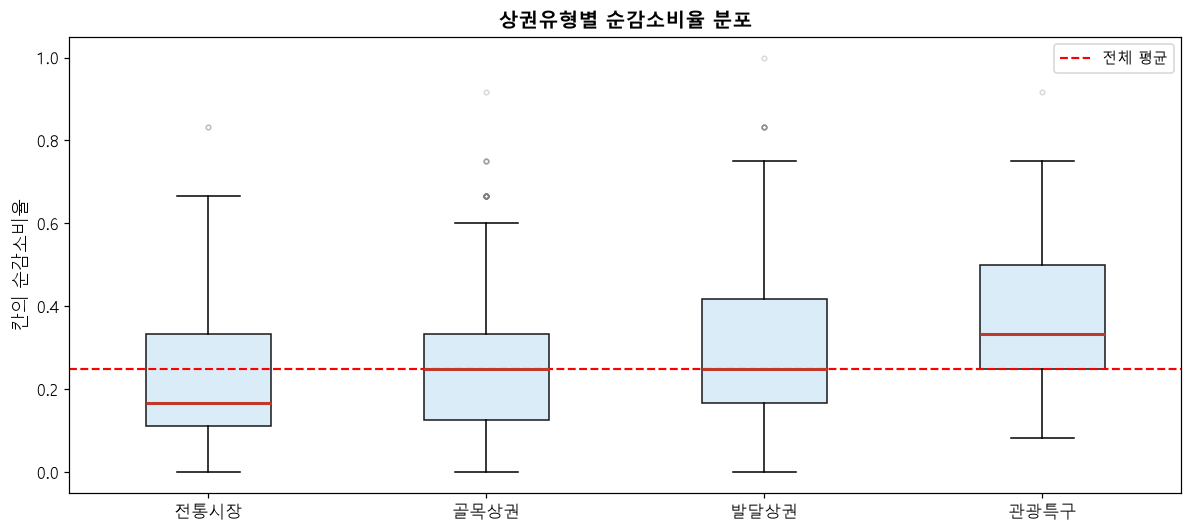

*그림 4*

읽는 법 — 상자 높이가 그룹마다 다른 것이 등분산성 위배의 모습이고, 위쪽에 흩어진 점들이 오른쪽 꼬리임.


### 해석

따라서 ANOVA는 참고값으로 두고, 정규성 가정을 덜 요구하는 Kruskal-Wallis를 중심으로 결론을 냈다. 이는 사후에 결과를 맞춘 선택이 아니라 사전 가정 점검에서 나온 선택이다.



## 08  가설 직접 검증 — 업종 × 상권유형 · 업종 × 자치구

**핵심 한 줄 — 같은 업종이라도 상권유형에 따라 위험이 달라지는 경우가 많았지만, 그 영향의 크기는 업종마다 크게 달랐다. 자치구 효과는 상대적으로 약했다.**

### 왜 이 분석을 했나

전체 업종을 섞으면 “업종 효과”와 “상권유형 효과”가 붙는다. 그래서 업종을 하나씩 고정한 뒤 상권유형 차이를 따로 검정했다.

### 핵심 결과

- 10개 업종 중 8개가 Bonferroni 보정 후에도 상권유형별 차이를 보였다.
- 호프·간이주점은 ε²=0.1202로 입지 차이가 비교적 컸고, 커피·음료 0.0652, 한식 0.0607이 뒤를 이었다.
- 치킨전문점은 ε²=0.0002로 차이가 사실상 없고 통계적으로도 유의하지 않았다.
- 골목상권 안에서 자치구를 비교한 분석은 확인 가능한 3개 업종 모두 Bonferroni 기준을 통과하지 못했다.

| 항목 | 핵심 수치 / 의미 |
|---|---|
| 상권유형 차이 | 10개 업종 중 8개 유의 |
| 가장 큰 효과 | 호프·간이주점 ε²=0.1202 |
| 거의 차이 없음 | 치킨전문점 ε²=0.0002 |
| 평균 효과크기 | 상권유형 0.0465 > 자치구 0.0211 |

*표 15*



,그룹수,H,n,p-value,유의,eps2
업종,,,,,,
호프-간이주점,3,86.9,709,0,True,0.1202
커피-음료,3,67.4,1006,0.000000000000002,True,0.0652
한식음식점,3,81,1306,0,True,0.0607
양식음식점,3,18.8,352,0.000081024701224,True,0.0483
분식전문점,3,32.5,637,0.000000088388986,True,0.0481
일식음식점,3,15.6,307,0.0004,True,0.0448
제과점,3,12.9,347,0.0015,True,0.0318
중식음식점,3,11,302,0.0041,True,0.03
패스트푸드점,3,7.1,322,0.0281,False,0.0161


*표 16*

읽는 법 — 업종을 하나로 고정하고 유형 간 차이를 검정한 결과임. 표본이 커서 p 는 거의 다 유의하므로 판정은 맨 오른쪽 eps2(효과크기) 열로 함.


### 해석

“모든 업종이 입지에 민감하다”는 결론은 틀리다. 상권유형의 영향을 많이 받는 업종과 거의 받지 않는 업종을 구분해야 한다. 자치구 결과는 표본이 줄어 검정력이 낮다는 한계도 함께 봐야 한다.



## 09  성향점수매칭 — 조건을 맞추고 다시 비교

**핵심 한 줄 — 한식음식점은 단순 비교에서는 더 위험해 보였지만, 규모와 입지가 비슷한 곳끼리 짝지으니 오히려 순감소 위험이 낮았다.**

### 왜 이 분석을 했나

업종별 상권 규모가 너무 달라 그대로 비교하면 “업종 차이”가 아니라 “큰 상권에 많이 들어가 있는가”를 비교하게 된다.

### 핵심 결과

- 한식음식점을 처리군으로 정하고 점포 수, 유동인구, 면적, 집객시설, 분기를 맞춰 1:1 매칭했다.
- 9,957개의 한식음식점 조합 중 6,836쌍이 매칭됐고, 매칭 후 모든 조건 변수의 |SMD|가 0.1 아래로 내려가 비교 가능한 수준이 됐다.
- 매칭 전 한식음식점은 +2.38%p 더 위험해 보였지만, 매칭 후 ATT는 −5.46%p로 방향이 반대로 바뀌었다.
- McNemar 검정, 상권 단위 부트스트랩 신뢰구간, 캘리퍼·복원 여부를 바꾼 다섯 설계가 모두 같은 방향을 보였다.

| 항목 | 핵심 수치 / 의미 |
|---|---|
| 매칭 쌍 | 6,836쌍 · 처리군 매칭률 68.7% |
| 단순 격차 | +2.38%p |
| 매칭 후 ATT | −5.46%p |
| 95% CI | −6.77%p ~ −3.81%p |
| 민감도 분석 | −5.59%p ~ −4.43%p |

*표 17*



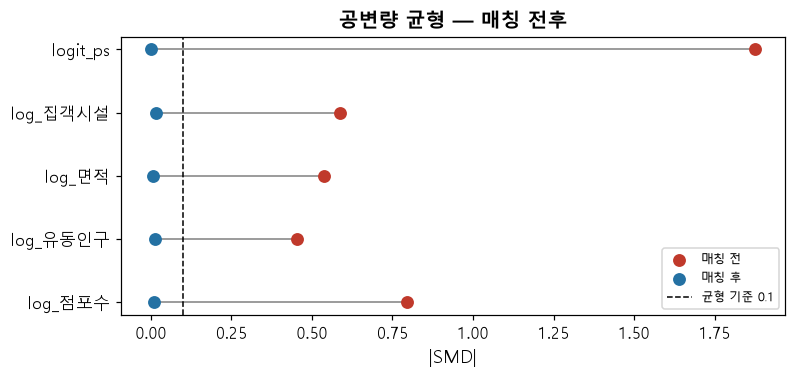

*그림 5*

읽는 법 — 붉은 점이 매칭 전, 파란 점이 매칭 후 |SMD| 임. 점선 0.1 왼쪽으로 모두 들어와야 비교가 성립함.


,쌍수,처리군_순감소율,대조군_순감소율,ATT(%p)
상권유형,,,,
골목상권,6848,0.228,0.282,-5.39
관광특구,50,0.34,0.46,-12
발달상권,1710,0.347,0.44,-9.3
전통시장,1422,0.211,0.296,-8.51


*표 18*

읽는 법 — 유형별로 따로 낸 ATT 임. 쌍이 50개뿐인 관광특구는 참고용이고, 나머지 세 유형에서 부호가 같은지가 판정 근거임.


### 해석

따라서 “한식음식점 자체가 위험하다”는 단순 해석은 지지되지 않았다. 다만 ATT는 매칭이 가능한 한식음식점 집단에서의 평균 차이이므로 모든 한식음식점에 그대로 일반화하는 데는 주의가 필요하다.



## 10  사후검정 — 어느 상권유형이 실제로 다른가

**핵심 한 줄 — 전체적으로 차이가 있다는 것만으로는 부족해, Dunn 사후검정으로 상권유형을 두 개씩 비교했다. 전통시장과 골목상권만 뚜렷하게 구분되지 않았다.**

### 왜 이 분석을 했나

Kruskal-Wallis는 “어딘가 다르다”까지만 알려준다. 정책적으로는 정확히 어느 유형과 어느 유형 사이가 다른지 알아야 한다.

### 핵심 결과

- 상권유형 4개에서 가능한 6쌍 중 5쌍이 Bonferroni 보정 후에도 유의했다.
- 전통시장과 골목상권은 p=0.321로 유의한 차이가 없었다.
- 발달상권은 전통시장·골목상권보다 높았고, 관광특구는 세 유형 모두보다 높았다.
- 골목상권 안의 자치구 25개를 쌍으로 비교한 300개 조합에서는 유의한 쌍이 3개(1.0%)뿐이었다.

| 항목 | 핵심 수치 / 의미 |
|---|---|
| 상권유형 결과 | {전통시장 ≈ 골목상권} < 발달상권 < 관광특구 |
| 유의한 유형 쌍 | 5/6 |
| 유의한 자치구 쌍 | 3/300 · 1.0% |
| 실무 단위 | 자치구보다 개별 상권 |

*표 19*



,median,mean,size
상권유형,,,
전통시장,0.1667,0.2176,775
골목상권,0.25,0.2282,2922
발달상권,0.25,0.2894,1932
관광특구,0.3333,0.3779,58


*표 20*

읽는 법 — 유형별 중앙값·평균·칸수임. 정렬은 중앙값이 낮은 쪽부터임.


,z,p(보정),유의,더 높은 쪽
쌍,,,,
전통시장 ↔ 발달상권,10.41,0,True,발달상권
전통시장 ↔ 관광특구,7.23,0,True,관광특구
골목상권 ↔ 발달상권,12.44,0,True,발달상권
골목상권 ↔ 관광특구,6.84,0,True,관광특구
발달상권 ↔ 관광특구,4.07,0.0003,True,관광특구
전통시장 ↔ 골목상권,1.93,0.321,False,골목상권


*표 21*

읽는 법 — 쌍마다의 z 와 보정 p, 그리고 어느 쪽이 더 높은지임. p 만 보면 방향을 알 수 없어 마지막 열을 함께 둠.


### 해석

위험을 관리할 때 자치구 전체를 한 덩어리로 보는 것보다 개별 상권을 직접 보는 편이 타당하다. 원문 결론의 순위 표기는 사후검정 표와 어긋나는 부분이 있어, 여기서는 쌍별 검정 결과에 맞춰 정리했다.



## 11  모델 선정

**핵심 한 줄 — 다섯 모델의 AP가 0.398~0.408에 몰려 있어 “어떤 알고리즘을 쓰느냐”보다 해석과 운영 설계가 더 중요했다.**

### 왜 이 분석을 했나

복잡한 모델이 단순 모델보다 확실히 우수한지 확인하고, 불균형 데이터에서 정확도 대신 적절한 평가 지표를 사용하기 위해 비교했다.

### 핵심 결과

- 의사결정나무, 랜덤포레스트, 로지스틱 회귀, 선형 SVM, XGBoost를 같은 검증 분기에서 비교했다.
- 양성 비율이 약 25%이므로 정확도는 주 지표로 쓰지 않았다. 모두 0으로 예측해도 정확도는 약 74.7%가 나오기 때문이다.
- 주 지표는 Precision-Recall 성능을 요약한 AP를 사용했다. 최고는 랜덤포레스트 0.408, XGBoost는 0.398이었다.
- 모델 간 차이가 0.01 수준으로 작아, 이후 변수 기여도 분석을 일관되게 연결하기 위해 XGBoost를 대표 모델로 사용했다.

| 항목 | 핵심 수치 / 의미 |
|---|---|
| 랜덤포레스트 | AP 0.408 |
| 선형 SVM | 0.406 |
| 로지스틱 회귀 | 0.406 |
| 의사결정나무 | 0.398 |
| XGBoost | 0.398 |

*표 22*



,AP,ROC-AUC,F1,정밀도,재현율,정확도,Lift
모델,,,,,,,
랜덤포레스트,0.408,0.676,0.401,0.401,0.401,0.697,1.584
선형 SVM,0.406,0.675,0.418,0.418,0.418,0.705,1.652
로지스틱 회귀,0.406,0.675,0.417,0.417,0.417,0.705,1.646
의사결정나무,0.398,0.667,0.420,0.401,0.441,0.692,1.585
XGBoost,0.398,0.665,0.405,0.405,0.405,0.699,1.601


*표 23*

읽는 법 — 다섯 모델을 같은 검증 분기에서 비교한 것이고 주지표는 AP 임. 정확도 열은 참고용임.


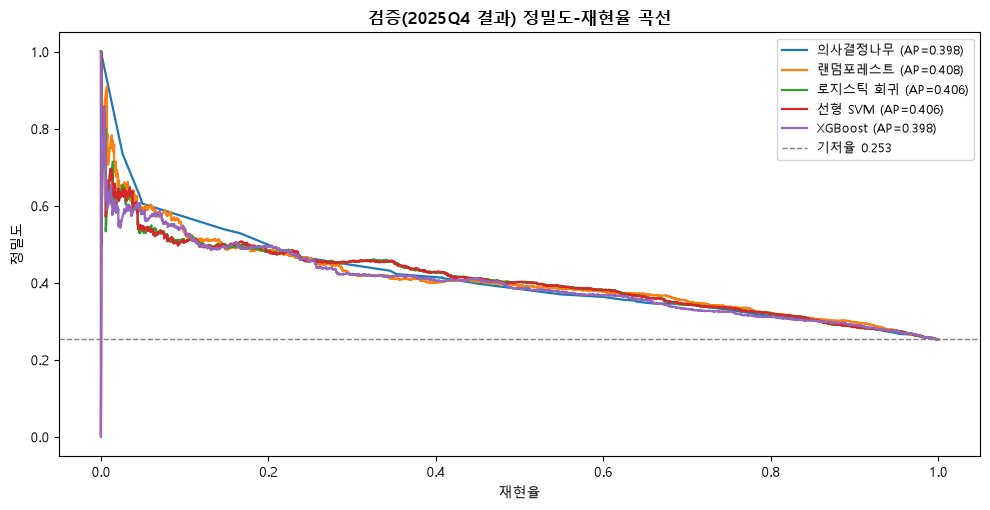

*그림 6*

읽는 법 — 곡선이 위로 붙을수록 좋고 점선이 기저율임. 다섯 곡선이 겹쳐 보이는 것이 «모델 선택이 결론을 바꾸지 않는다»는 근거임.


### 해석

오버샘플링은 분할 전에 적용하지 않았고, 모델별 클래스 가중치로 불균형을 다뤘다. 중요한 결론은 “XGBoost가 최고”가 아니라, 서로 다른 모델의 성능이 거의 같아 현재 성능 한계가 알고리즘보다 데이터 변수에 더 가까워 보인다는 점이다.



## 12  선정 규모 — 몇 곳을 위험 대상으로 볼 것인가

**핵심 한 줄 — 모델은 많은 곳을 넓게 잡을 때보다, 실제 담당자가 볼 수 있는 상위 수십~수백 곳을 우선 선별할 때 가장 유용했다.**

### 왜 이 분석을 했나

경보 대상을 몇 곳으로 자르느냐에 따라 정밀도와 재현율이 달라진다. 테스트 결과를 본 뒤 기준을 고르면 과적합이므로, 선정 규모는 검증 분기에서 먼저 정했다.

### 핵심 결과

- 검증에서 정밀도가 가장 높았던 기준은 상위 100개였다. 이 기준을 테스트 분기에 그대로 적용했다.
- 테스트에서 상위 50개는 모델 정밀도 72.0%로 점포 수 기준 38.0%보다 높았다.
- 상위 100개는 60.0% vs 46.0%, 상위 300개는 53.3% vs 49.3%였다.
- 선정 규모가 커질수록 모델과 점포 수 기준의 차이가 줄었고, 상위 800개 이후에는 점포 수 기준이 더 높아졌다.

| 항목 | 핵심 수치 / 의미 |
|---|---|
| 상위 50개 | 모델 72.0% · 점포 수 38.0% |
| 상위 100개 | 60.0% · 46.0% |
| 상위 300개 | 53.3% · 49.3% |
| 상위 100개 재현율 | 전체 실제 순감소의 4.2%만 포착 |

*표 24*



,검증 정밀도,검증 재현율,검증 ÷ 기저율
위험으로 찍은 수,,,
50,0.580,0.021,2.292
100,0.600,0.043,2.371
200,0.555,0.080,2.193
300,0.513,0.111,2.028
500,0.488,0.175,1.928
800,0.448,0.257,1.768
1285,0.412,0.380,1.627
2000,0.378,0.543,1.494


*표 25*

읽는 법 — 검증 분기에서 찍는 칸 수를 바꿔 가며 정밀도를 본 것임. 가장 높은 지점(상위 100칸)을 테스트로 옮겨 씀.


,XGBoost 정밀도,점포 수 정밀도,XGBoost 재현율,점포 수 재현율,XGBoost ÷ 기저율,점포 수 ÷ 기저율,두 목록 겹침,XGBoost 평균점포
위험으로 찍은 수,,,,,,,,
50,0.720,0.380,0.025,0.013,2.772,1.463,0.100,108.620
100,0.600,0.460,0.042,0.032,2.310,1.771,0.230,100.980
200,0.575,0.520,0.081,0.073,2.214,2.002,0.360,82.425
300,0.533,0.493,0.112,0.104,2.054,1.899,0.413,74.143
500,0.494,0.464,0.174,0.163,1.902,1.787,0.516,65.012
800,0.441,0.459,0.248,0.258,1.699,1.766,0.619,57.014
1285,0.398,0.427,0.359,0.386,1.531,1.645,0.687,47.151
2000,0.376,0.383,0.528,0.538,1.448,1.475,0.742,38.217


*표 26*

읽는 법 — 테스트 분기 결과임. «두 목록 겹침» 열이 모델과 점포 수 규칙이 같은 칸을 찍는 비율이고, 많이 찍을수록 1 에 가까워짐.


### 해석

따라서 상위 100~300개 목록은 “모든 위험상권을 찾는 명단”이 아니라 “먼저 연락하거나 점검할 우선순위 목록”으로 써야 한다. 정밀도를 높이면 놓치는 위험상권도 많아지는 trade-off를 함께 보고해야 한다.



## 13  테스트 최종 평가 — 2026년 1분기 결과

**핵심 한 줄 — 학습과 모델 선택에 쓰지 않은 홀드아웃 분기에서 AP 0.399, Lift 1.522를 기록했다. 전체 순위 성능은 점포 수 기준과 비슷했지만, 상위 소수 구간에서는 모델이 더 강했다.**

### 왜 이 분석을 했나

학습 2023Q1~2025Q2, 검증 2025Q3, 테스트 2025Q4로 시간을 섞지 않고 나눴다. 2025Q4 행은 2026Q1의 실제 결과로 채점했다.

### 핵심 결과

- 테스트 AP는 0.399, ROC-AUC는 0.648이었다.
- 기본 임계값 기준 정밀도 39.5%, 재현율 37.2%, F1 0.384였다.
- 전체적인 넓은 선정 기준에서는 점포 수 Lift 1.645가 XGBoost 1.522보다 높았다.
- 하지만 앞 절의 상위 50~500개 같은 실무 구간에서는 모델 정밀도가 점포 수 기준보다 높았다.

| 항목 | 핵심 수치 / 의미 |
|---|---|
| AP | 0.399 |
| ROC-AUC | 0.648 |
| 정밀도 / 재현율 | 39.5% / 37.2% |
| F1 | 0.384 |
| Lift | 1.522 |
| 혼동행렬 | TP 530 · FP 811 · FN 893 · TN 3,245 |

*표 27*



,테스트(2026Q1 결과)
AP,0.399
ROC-AUC,0.648
정밀도,0.395
재현율,0.372
F1,0.384
정확도,0.689
Lift,1.522


*표 28*

읽는 법 — 테스트 분기에서 채택 모델·검증 1위 모델·기준선 셋을 나란히 놓은 것임.


### 해석

모델이 “전체 상권을 완벽하게 줄 세운다”고 말할 수는 없다. 정확한 결론은 “상위 소수 위험군을 우선 선별하는 데 추가 가치가 있으며, 넓게 선정하면 규모 기준과 차이가 줄어든다”이다. 또한 테스트가 한 분기뿐이므로 추가 분기 검증이 필요하다.



## 14  두 단계로 나눈 모형

**핵심 한 줄 — 순감소를 “① 다음 분기에 개·폐업이 일어나는가”와 “② 일어났다면 감소 방향인가”로 나누자, 상권 규모 효과가 대부분 1단계에 모여 있음을 확인했다.**

### 왜 이 분석을 했나

기존 라벨은 “사건 발생”과 “감소 방향”이 합쳐져 있어 큰 상권이 자동으로 위험해 보이는 문제가 있다.

### 핵심 결과

- 1단계는 P(개업 또는 폐업 사건), 2단계는 P(순감소 | 사건)를 예측한다. 최종 순감소 확률은 두 값을 곱한다.
- 실제 데이터에서도 P(사건)=0.5608, P(순감소|사건)=0.4543이고 두 값을 곱한 0.2548이 전체 순감소율 0.2548과 정확히 일치했다.
- 점포 수와의 상관은 사건 여부 +0.448이었지만, 사건이 발생한 뒤 감소 방향과는 −0.039로 거의 관계가 없었다.
- 검증 AP는 단일 XGBoost 0.398, 2단계 0.405로 차이는 +0.007에 그쳤다. 1단계 사건모형 AP는 0.810이었다.

| 항목 | 핵심 수치 / 의미 |
|---|---|
| 1단계 | P(사건) · 규모 영향 큼 |
| 2단계 | P(순감소 | 사건) · 규모 영향 거의 없음 |
| 최종 확률 | 두 확률의 곱 |
| 검증 AP | 단일 0.398 → 2단계 0.405 |

*표 29*



,AP,ROC-AUC,정밀도,재현율,Lift
방법,,,,,
단일 모형 (XGBoost),0.398,0.665,0.405,0.405,1.601
2단계 모형,0.405,0.673,0.421,0.421,1.663


*표 30*

읽는 법 — 단일 모형과 2단계 모형을 같은 검증 분기에서 비교한 것임. 차이가 작다는 점이 핵심이고, 나누는 이유는 성능이 아니라 규모 편향의 분리임.


### 해석

2단계 모형의 가장 큰 장점은 성능 향상보다 해석이다. “큰 상권이라 사건이 자주 생기는 효과”와 “사건이 생겼을 때 실제로 감소 쪽으로 기우는 위험”을 분리할 수 있다.



## 15  두 확률로 나눈 상권 유형

**핵심 한 줄 — 최종 위험점수 하나로만 줄 세우지 않고 “변화가 자주 생기는가”와 “변하면 감소하는가”를 두 축으로 남기면 성격이 다른 네 유형을 구분할 수 있다.**

### 왜 이 분석을 했나

두 확률을 곱하면 점포가 많은 상권이 앞에 오기 쉽다. 그러면 규모는 작지만 변화가 생겼을 때 취약한 상권이 뒤로 밀려난다.

### 핵심 결과

- 검증 분기 중앙값을 기준으로 사건확률 0.4259, 순감소 조건부확률 0.5045에서 네 유형을 나눴다.
- “안정적” 1,229개, “정체되어 있으나 변화 시 취약” 1,535개, “활발하게 변하나 성장·유지” 1,529개, “활발하게 변하면서 쇠퇴” 1,186개였다.
- 실제 순감소율은 각각 16.6%, 19.2%, 31.9%, 36.8%였다.
- 골목상권에서는 “정체·취약형”이 34.7%로 가장 큰 비중을 차지했고 평균 점포 수는 7.6개에 불과했다.

| 항목 | 핵심 수치 / 의미 |
|---|---|
| 안정적 | 사건↓ 방향↓ · 1,229개 · 실제 16.6% |
| 정체·취약 | 사건↓ 방향↑ · 1,535개 · 19.2% |
| 활발·성장/유지 | 사건↑ 방향↓ · 1,529개 · 31.9% |
| 활발·쇠퇴 | 사건↑ 방향↑ · 1,186개 · 36.8% |

*표 31*



표 32

*표 32*

읽는 법 — 네 유형의 칸수와 실제 순감소율이며 마지막 열이 기저율 대비임. 이름 순서대로 순감소율이 오르면 두 축이 제 역할을 한 것임.


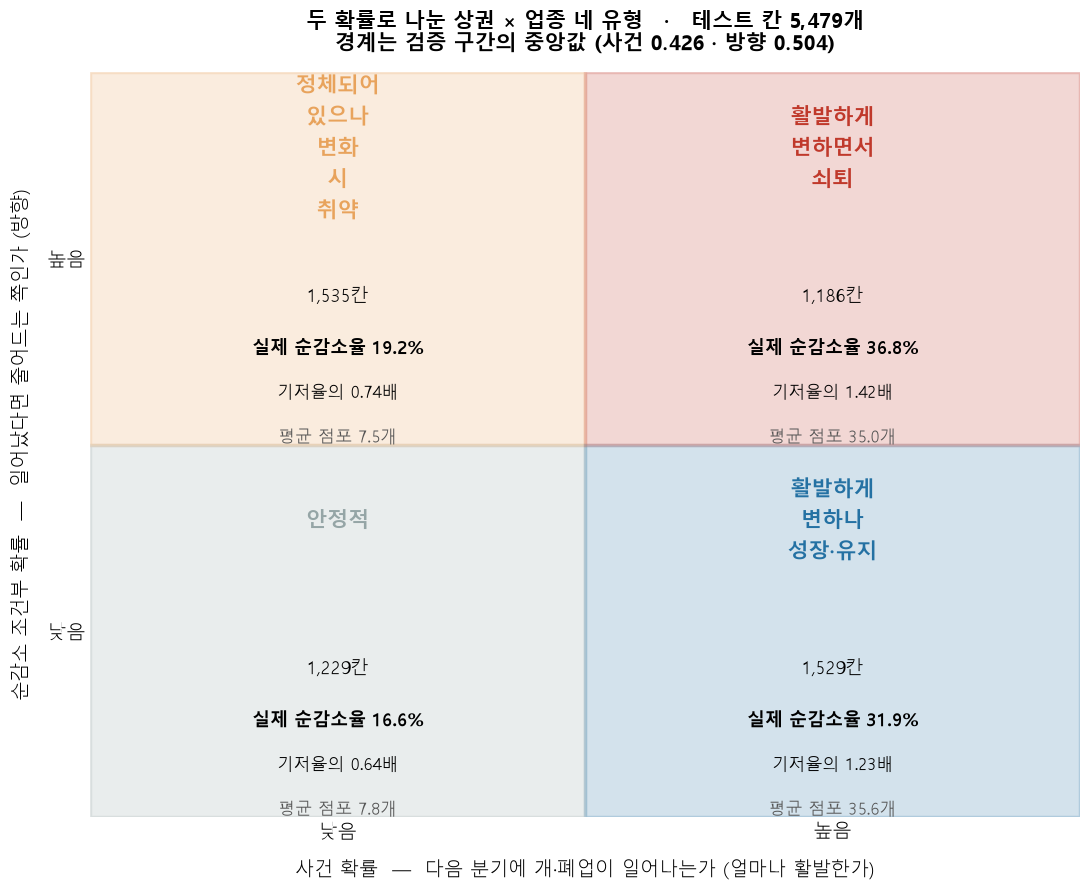

*그림 7*

읽는 법 — 가로축이 사건 확률, 세로축이 순감소 조건부 확률임. 검증 분기 중앙값 두 선이 네 칸을 만들고, 왼쪽 위 칸이 «정체되어 있으나 변화 시 취약»임.


### 해석

정책적으로는 오른쪽 위 “활발·쇠퇴형”을 즉시 점검하고, 왼쪽 위 “정체·취약형”은 별도 관찰목록으로 관리하는 방식이 가능하다. 같은 최종 위험점수라도 두 유형은 필요한 대응이 다르다.



## 16  무엇이 위험과 관련되어 있는가

**핵심 한 줄 — 단일 모델에서는 규모·밀도 변수가 기여도의 절반 이상을 차지했지만, 사건과 방향을 분리하자 규모 영향은 주로 1단계에 남고 2단계에서는 크게 줄었다.**

### 왜 이 분석을 했나

변수 중요도를 그대로 “원인”으로 읽으면 안 된다. SHAP은 모델이 예측할 때 어떤 변수를 얼마나 사용했는지를 보여 주는 설명 도구다.

### 핵심 결과

- 단일 모형에서 규모·밀도 관련 변수의 SHAP 기여 비중은 53.1%였다.
- 1단계 사건모형에서는 규모·밀도 비중이 65.4%로 더 커졌다. 반면 2단계 “사건 발생 후 감소 방향”에서는 38.3%까지 낮아졌다.
- 2단계에서 규모 변수를 제외하고 보면 한식 업종 여부, 외식물가지수, 현재 순감소 상태, 커피 업종 여부, 점포당 매출, 업종점포비중 등이 상위에 나타났다.
- 전국 단위 경제지표는 같은 분기 안에서 모든 상권에 같은 값이 들어가므로, 상권 간 순위를 바꾸는 정보로는 제한적이다.

| 항목 | 핵심 수치 / 의미 |
|---|---|
| 규모·밀도 기여 | 단일 53.1% |
| 1단계 P(사건) | 65.4% |
| 2단계 P(순감소|사건) | 38.3% |
| 2단계 핵심 방향 | 점포당 매출·업종 구성·업종 특성의 상대적 중요도 상승 |

*표 33*



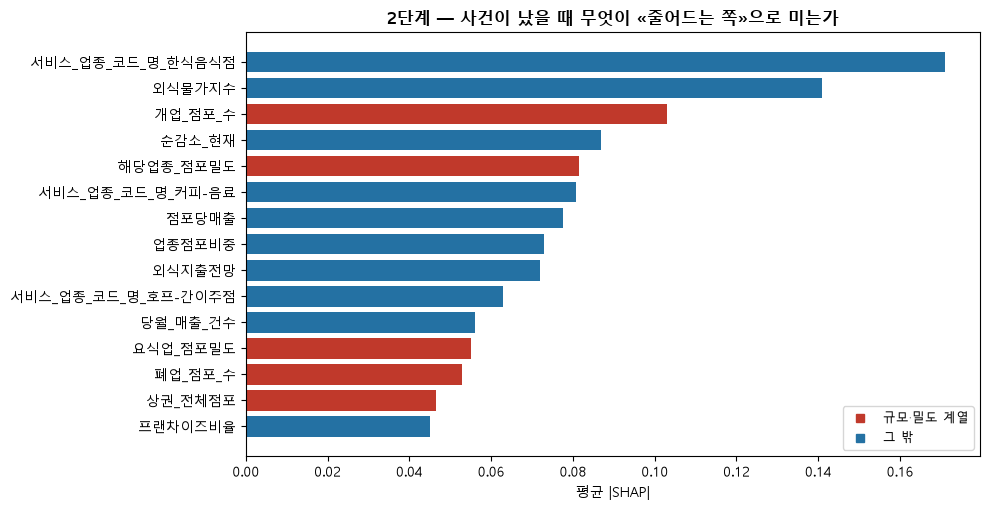

*그림 8*

읽는 법 — 2단계에서 붉은 막대가 규모·밀도 계열임. 위쪽에 파란 막대가 오면 그것이 «크기와 무관한 위험 요인»임.


,2단계 평균 |SHAP|
서비스_업종_코드_명_한식음식점,0.1710
외식물가지수,0.1408
순감소_현재,0.0869
서비스_업종_코드_명_커피-음료,0.0807
점포당매출,0.0775
업종점포비중,0.0730
외식지출전망,0.0720
서비스_업종_코드_명_호프-간이주점,0.0628
당월_매출_건수,0.0561
프랜차이즈비율,0.0450


*표 34*

읽는 법 — 규모 계열을 뺀 2단계 상위 목록임. 정책적으로 읽을 값은 이 목록임.


### 해석

따라서 “위험을 만드는 원인”이라고 단정하기보다 “규모 효과를 분리한 뒤에도 모델이 위험 판단에 사용한 요인”이라고 표현하는 것이 정확하다. 인과효과를 말하려면 별도의 인과설계가 필요하다.



## 17  위험도 공간 분석

**핵심 한 줄 — 지도에서는 위험등급이 높아질수록 실제 순감소율도 15.3% → 39.3%로 증가했다. 다만 자치구 경계나 역과의 거리 자체는 위험을 잘 설명하지 못했다.**

### 왜 이 분석을 했나

예측 결과가 실제 공간에서 어디에 모이는지 확인하고, 행정구역·역세권 같은 단순 입지 기준으로 대체할 수 있는지 점검했다.

### 핵심 결과

- 원본 좌표계는 EPSG:5181로 확인했고, 서울 안 5,479개 상권×업종 조합을 지도 분석에 사용했다.
- 위험점수 4분위로 나눈 실제 순감소율은 관찰 15.3% → 주의 19.4% → 경계 29.9% → 위험 39.3%로 단조 증가했다.
- 상권 경계 폴리곤이 없어 점·버블·500m 격자 등으로 분포를 표현했으며, 자치구 외곽선은 위치 확인용 근사치라 면적 계산에는 쓰지 않았다.
- 역 밖 0~250m, 250~500m, 500m~1km, 1km 초과 구간에서 위험이 일정하게 증가하는 패턴은 없었다. 역세권 상권의 높은 위험은 평균 점포 수가 큰 규모 효과로 해석됐다.

| 항목 | 핵심 수치 / 의미 |
|---|---|
| 좌표계 | EPSG:5181 |
| 지도 표본 | 5,479개 |
| 위험등급 실제 순감소율 | 15.3% → 19.4% → 29.9% → 39.3% |
| 역 거리 효과 | 뚜렷한 거리 구배 없음 |

*표 35*



,칸수,평균위험점수,실제순감소율,평균점포,기저율대비
위험등급,,,,,
관찰,1370,0.209,0.153,8.547,0.59
주의,1370,0.345,0.194,12.060,0.75
경계,1369,0.461,0.299,19.187,1.15
위험,1370,0.643,0.393,45.672,1.51


*표 36*

읽는 법 — 위험등급별 실제 순감소율이 단조 증가하는지 보는 표임. 증가하지 않으면 등급 경계를 다시 잡아야 함.


,상권수,평균위험,실제순감소율,평균점포
역거리_구간,,,,
역세권 상권,191,0.623,0.414,53.419
0~250m,66,0.430,0.227,19.212
250~500m,370,0.475,0.273,21.095
500m~1km,519,0.468,0.295,21.383
1km 초과,211,0.434,0.294,18.569


*표 37*

읽는 법 — 역거리 구간별 평균 위험과 평균 점포임. 첫 줄(역세권 상권)만 점포 수가 두 배 이상 큼.


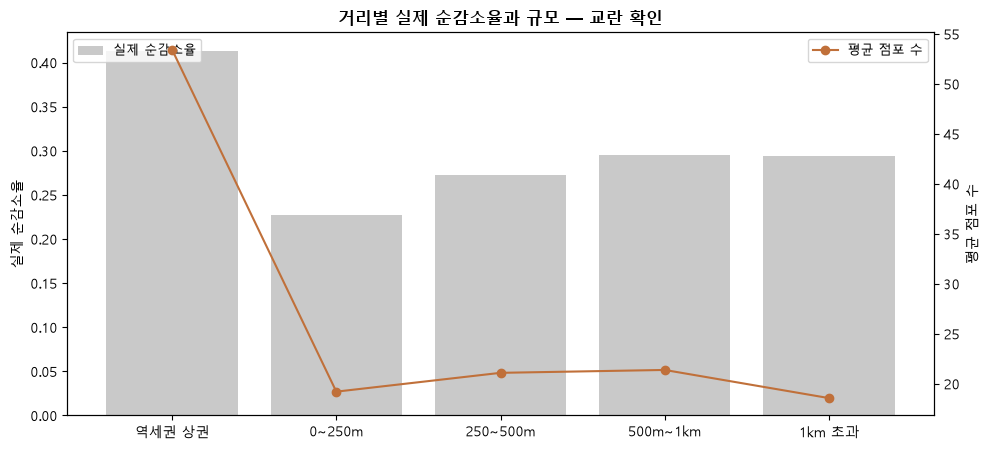

*그림 9*

읽는 법 — 회색 막대가 실제 순감소율, 주황 선이 평균 점포 수임. 두 줄이 같이 움직이면 거리 효과가 아니라 규모 효과라는 뜻임.


### 해석

지도는 “어느 상권을 먼저 볼 것인가”를 보여 주는 도구로는 유용하지만, 자치구 전체가 위험하다고 해석하거나 정확한 면적 효과를 계산하는 데는 현재 자료가 부족하다.



## 18  종합 결론

**핵심 한 줄 — 다음 분기 순감소를 완벽하게 예측한 것은 아니지만, 상위 소수 고위험 상권을 한 분기 먼저 선별하고 규모에 가려진 위험 구조를 분리해 설명할 수 있었다.**

### 왜 이 분석을 했나

이 연구의 결론은 “모델이 좋다/나쁘다” 한 줄이 아니라, 어디까지 예측할 수 있고 무엇을 통제해야 하며 실제 운영에서 어떻게 써야 하는지를 함께 제시하는 것이다.

### 핵심 결과

- Q1 예측 가능성: 상위 100개 정밀도 60.0%로 전체 평균 26.0%의 2.31배였다. 다만 넓게 선정하면 점포 수 기준과 차이가 줄어든다.
- Q2 상권유형: 규모를 통제하기 전과 후의 결론이 달라졌다. 골목상권은 단순 비교 OR 0.813이었지만 규모 통제 후 공통 OR 1.061이었고, 규모별 효과도 서로 달랐다.
- 업종 효과: 한식음식점은 단순 비교 +2.38%p에서 PSM 후 ATT −5.46%p로 바뀌었다. “업종 자체의 위험”처럼 보였던 상당 부분이 규모·입지 차이였다.
- Q3 동일 업종의 입지 효과: 10개 중 8개 업종에서 상권유형 차이가 있었지만, 호프·간이주점처럼 큰 업종과 치킨전문점처럼 거의 없는 업종이 함께 존재했다.
- 2단계 모형: 규모 효과는 주로 “사건이 생기는가”에 몰려 있었고, “사건이 생긴 뒤 감소하는가”에서는 크게 줄었다.
- 정책 단위: 자치구보다 개별 상권이 적절하며, 상위 100~300개를 우선 점검 목록으로 사용하고 네 가지 상권 유형에 따라 관리 강도를 달리하는 방식이 타당하다.

| 항목 | 핵심 수치 / 의미 |
|---|---|
| 가장 실용적인 사용법 | 상위 100~300개 우선 점검 + 4유형 별도 관리 |
| 가장 중요한 통계 교훈 | 규모를 통제하지 않으면 상권유형·업종의 결론 방향이 반대로 나올 수 있음 |
| 기존 지표와 차이 | 서울시 HL 지표는 다음 분기 선별 Lift 0.937로 낮아 목적이 다름 |
| 핵심 한계 | 테스트 1개 분기 · 사업자등록 말소 시차 · 카드매출 추정 · 상권 폴리곤 부재 |

*표 38*



### 해석

최종적으로 이 모델은 “전수 판정기”보다 “다음 분기에 먼저 확인할 상권을 좁혀 주는 조기경보 도구”로 보는 것이 맞다. 다음 단계는 새로운 분기가 들어올 때마다 성능을 재검증하고, 상권별 임대료·온라인 관심도처럼 같은 분기 안에서도 지역별로 달라지는 변수를 추가하는 것이다.

